## __Tópicos avanzados en Inteligencia Artificial 1 - MIA__

__Profesor__: Anthony D. Cho

__Ayudante__: Luis Oliveros

__Asunto__: Vision Transformer (ViT) - Fish Disease

***

## Librerias

In [ ]:
import os
from glob import glob
from time import time
import matplotlib.pyplot as plt
from numpy import zeros, array, sqrt, random, argmax

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical

## Funciones personalizadas

In [ ]:
def plot_history(history, width=12, height=6):
  """
  DESCRIPTION:
    History performance of the keras model

  INPUT:
    @param history: history of performance of fitted model
    @type history: tensorflow.python.keras.callbacks.History

  OUTPUT:
    A graphic
  """

  ## Metrics keys stored in tensorflow object
  keys = list(history.history.keys())

  ## Number of epoch used for fit the model
  epoch = range(1, len(history.epoch) +1)

  ## Check if validation set was used.
  withValidation = False
  for key in keys:
    if 'val' in key:
      withValidation = True

  ## Number of metrics
  nMetrics = len(keys)
  if withValidation:
    nMetrics = nMetrics//2

  ## Plot-space instance
  plt.figure(figsize=(width, height))

  for i in range(nMetrics):
    plt.subplot(nMetrics, 1, i+1)

    ## Plot (train) metric value
    labelMetric = keys[i]
    metric = history.history[keys[i]]
    plt.plot(epoch, metric, 'o-', label=labelMetric)

    if withValidation:
      ## Plot (validation) metric value
      labelMetricVal = keys[i+nMetrics]
      metricVal = history.history[keys[i+nMetrics]]
      plt.plot(epoch, metricVal, 'o-', label=labelMetricVal)

    plt.xlim(epoch[0], epoch[-1])
    plt.legend()
    plt.grid()

  plt.xlabel('Epoch')
  plt.show()

In [ ]:
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))


# Dataset

Source: [Freshwater Fish Disease Aquaculture in south asia](https://www.kaggle.com/datasets/subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia) (Kaggle) <br>

<p style="color:red"> <b>Instrucciones para usuarios que usan Windows: </b></p>

* Descargar la data pulsando [¡¡AQUI!!](https://mayorcl-my.sharepoint.com/:u:/g/personal/anthony_cho_umayor_cl/EQaLMBW_z_5GqcgddltVJN0BYDr2lPYmEN6Sjp8Rcc_CMg?download=1)
* Descomprime el archivo __freshwater-fish-disease.zip__. Luego, dejarla carpeta de imágenes __SB-FishDisease__ junto con el script.
* Ya con eso, debería poder ejecutar el script sin ningun problema.

In [ ]:
## Solo para Linux y MacOS
if os.name == 'posix':
    if not os.path.exists("freshwater-fish-disease.zip"):
        ## Download files

        !wget https://mayorcl-my.sharepoint.com/:u:/g/personal/anthony_cho_umayor_cl/EQaLMBW_z_5GqcgddltVJN0BYDr2lPYmEN6Sjp8Rcc_CMg?download=1

        !mv EQaLMBW_z_5GqcgddltVJN0BYDr2lPYmEN6Sjp8Rcc_CMg?download=1 freshwater-fish-disease.zip

        ## un-compress joined zip file
        !unzip freshwater-fish-disease.zip

    else:
        print('El archivo "freshwater-fish-disease.zip" ya existe en su carpeta.')

else:
    print('Seguir las instrucciones para usuarios de Windows mencionado arriba.')

El archivo "freshwater-fish-disease.zip" ya existe en su carpeta.


In [ ]:
## Rutas de los archivos
file_paths = glob('SB-FishDisease/**/*.*', recursive=True)

## Mostrar la cantidad de imagenes
print('Size of dataset: {}'.format(len(file_paths)))

Size of dataset: 460


In [ ]:
## Almacenamiento de etiquetas reales
y_label = []

if os.name == 'posix': ## Si es Linux o MacOS
  for filename in file_paths:
    label = filename.split('/')[-2]
    y_label.append(label)

else: ## Si es windows
  for filename in file_paths:
    label = filename.split('//')[-2]
    y_label.append(label)

In [ ]:
Counter(y_label)

Counter({'Viral diseases White tail disease': 44,
         'Bacterial gill disease': 58,
         'Healthy Fish': 177,
         'Bacterial Red disease': 48,
         'Fungal diseases Saprolegniasis': 46,
         'Parasitic diseases': 38,
         'Bacterial diseases - Aeromoniasis': 49})

In [ ]:
## Lista
disease_names = list(Counter(y_label).keys())

## Codificación a numerica
y_encoded = array([disease_names.index(v) for v in y_label])
print(y_encoded)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6]


In [ ]:
## Numero de clases
num_classes = len(disease_names)
print(f'Numero de clases: {num_classes}')

Numero de clases: 7


## Carga de imágenes

In [ ]:
## Tamaño de la imagen reajustada
input_shape = 224

## Cargar Train Data
X = zeros((len(file_paths), input_shape, input_shape, 3))
for i, file in enumerate(file_paths):

    ## Cargar imagen y reshape
    img = load_img(file, target_size=(input_shape, input_shape))

    ## Convertir de imagen a arreglo
    img = img_to_array(img)

    ## Almacenar matriz de imagen
    X[i] = img

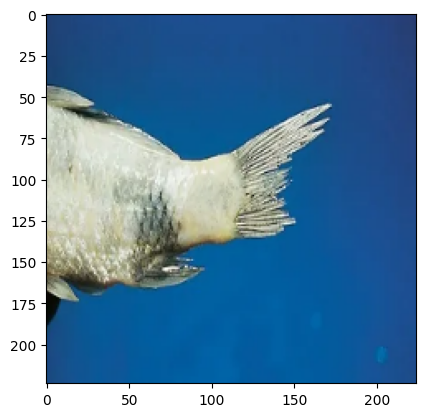

In [ ]:
plt.imshow(X[0].astype('uint8'))
plt.show()

#### Particion de los datos

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
                                                    test_size=0.1,
                                                    stratify=y_encoded)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                 test_size=0.1,
                                                 stratify=y_train)


print('(shape - Train) X: {} - y: {}'.format(X_train.shape, y_train.shape))
print('(shape - Val) X: {} - y: {}'.format(X_val.shape, y_val.shape))
print('(shape - Test) X: {} - y: {}'.format(X_test.shape, y_test.shape))

(shape - Train) X: (372, 224, 224, 3) - y: (372,)
(shape - Val) X: (42, 224, 224, 3) - y: (42,)
(shape - Test) X: (46, 224, 224, 3) - y: (46,)


In [ ]:
## Codificación One-Hot
y_train_enc = to_categorical(y_train)
y_val_enc = to_categorical(y_val)
y_test_enc = to_categorical(y_test)

print('(OHE - Train) y: {}'.format(y_train_enc.shape))
print('(OHE - Val) y: {}'.format(y_val_enc.shape))
print('(OHE - Test) y: {}'.format(y_test_enc.shape))

(OHE - Train) y: (372, 7)
(OHE - Val) y: (42, 7)
(OHE - Test) y: (46, 7)


## Diseño del modelo

Basado en la implementación de [Khalid Salama](https://keras.io/examples/vision/image_classification_with_vision_transformer/)

#### Settings

In [ ]:
## Hiperparametros para los parches
image_size = 72
patch_size = 6  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2

## Hiperparametros para el transformer
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8

## Hiperparmetros para la configuración del optimizador
batch_size = 32
num_epochs = 1000
learning_rate = 0.001
weight_decay = 0.0001

## Capa del clasificador
mlp_head_units = [2048, 1024]  # Size of the dense layers of the final classifier


#### Capa para data augmentation

In [ ]:
data_augmentation = Sequential(
    [
        layers.Normalization(),
        layers.Resizing(height=image_size, width=image_size),
        layers.RandomFlip(mode="horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2,
                          width_factor=0.2),
    ],
    name="data_augmentation",
)

# Compute the mean and the variance of the training data for normalization.
#data_augmentation.layers[0].adapt(X_train)

#### Capa para la creación de los parches

In [ ]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        ## Extractor de parches
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        patch_dims = patches.shape[-1]

        ## Aplanado de cada parche (batch_size, patch_features_flatten)
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


###### Verificación de respuesta de la capa

Image shape: (224, 224, 3)
Patch shape: 6 X 6
Patches per image: 144
Elements per patch: 108



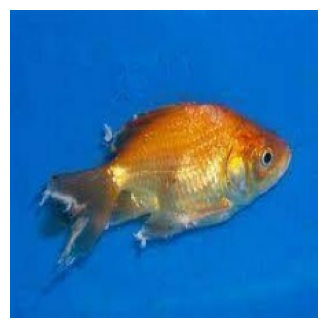

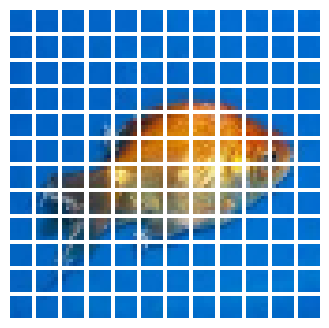

In [ ]:
## Mostrar una imagen en formato original
plt.figure(figsize=(4, 4))
image = X_train[random.choice(range(X_train.shape[0]))]
plt.imshow(image.astype("uint8"))
plt.axis("off")

## Redimensionado de la imagen
resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(image_size, image_size)
)

## Procesar la imagen mediante la capa diseñada para parches
patches = Patches(patch_size)(resized_image)

print(f"Image shape: {image.shape}")
print(f"Patch shape: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}\n")

n = int(sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")

## Capa de Embedding para parche

In [ ]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches

        ## Proyeccion lineal usado para parches (embedding de parche)
        self.projection = layers.Dense(units=projection_dim)

        ## Embedding de posición de los parches
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        ## Aplicación del embedding de parche y la posición.
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded


## Capa de MLP usado dentro del transformer y discriminador (clasificador)

In [ ]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

#### Armado del modelo

In [ ]:
## Input layer instance
inputs = layers.Input(shape=X_train.shape[1:], name='Input')

## Augment data.
augmented = data_augmentation(inputs)

## Create patches.
patches = Patches(patch_size)(augmented)

## Encode patches.
encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

## Create multiple layers of the Transformer block.
for _ in range(transformer_layers):

    # Layer normalization 1.
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

    # Create a multi-head attention layer.
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=0.1
    )(x1, x1)

    # Skip connection 1.
    x2 = layers.Add()([attention_output, encoded_patches])

    # Layer normalization 2.
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

    # MLP.
    x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
    # Skip connection 2.
    encoded_patches = layers.Add()([x3, x2])

# Create a [batch_size, projection_dim] tensor.
representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.5)(representation)

# Add MLP.
features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)

# Classify outputs.
output = layers.Dense(num_classes, activation='softmax', name='output')(features)

# Create the Keras model.
model = Model(inputs=inputs, outputs=output)

In [ ]:
## Mostrar resumen del modelo
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 Input (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 data_augmentation (Sequent  (None, 72, 72, 3)            7         ['Input[0][0]']               
 ial)                                                                                             
                                                                                                  
 patches_2 (Patches)         (None, None, 108)            0         ['data_augmentation[1][0]']   
                                                                                                  
 patch_encoder_1 (PatchEnco  (None, 144, 64)              16192     ['patches_2[0][0]']     

#### Configuración para el compilador

In [ ]:
## Instancia del optimizador
optimizer = AdamW(learning_rate=learning_rate,
                  weight_decay=weight_decay)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy', f1_m],
    )

## Instancia para el checkpoint del modelo
checkpoint_filepath = 'ViT {epoch:02d}.h5'
checkpoint_callback = ModelCheckpoint(
    checkpoint_filepath,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
)

#### Ajuste del modelo

Tarda alrededor de 20 minutos (GPU)

In [ ]:
start = time()

history = model.fit(x=X_train, y=y_train_enc,
                    batch_size=batch_size,
                    epochs=num_epochs,
                    validation_data=[X_val, y_val_enc],
                    callbacks=[checkpoint_callback]
                    )

timeUp = time()
print('Time spent[s]: {}'.format(timeUp - start))

Epoch 1/1000
12/12 [==============================] - 29s 280ms/step - loss: 17.1517 - accuracy: 0.2151 - f1_m: 0.2054 - val_loss: 3.9268 - val_accuracy: 0.1429 - val_f1_m: 0.1333
Epoch 2/1000
12/12 [==============================] - 2s 127ms/step - loss: 4.7628 - accuracy: 0.2151 - f1_m: 0.2056 - val_loss: 2.5308 - val_accuracy: 0.3810 - val_f1_m: 0.4274
Epoch 3/1000
12/12 [==============================] - 4s 313ms/step - loss: 3.7527 - accuracy: 0.2312 - f1_m: 0.2139 - val_loss: 1.8347 - val_accuracy: 0.4048 - val_f1_m: 0.0303
Epoch 4/1000
12/12 [==============================] - 1s 86ms/step - loss: 2.7040 - accuracy: 0.2285 - f1_m: 0.1886 - val_loss: 1.8364 - val_accuracy: 0.3810 - val_f1_m: 0.0303
Epoch 5/1000
12/12 [==============================] - 1s 81ms/step - loss: 2.0665 - accuracy: 0.2769 - f1_m: 0.1891 - val_loss: 1.7477 - val_accuracy: 0.4048 - val_f1_m: 0.0000e+00
Epoch 6/1000
12/12 [==============================] - 1s 120ms/step - loss: 2.0150 - accuracy: 0.3226 - f1

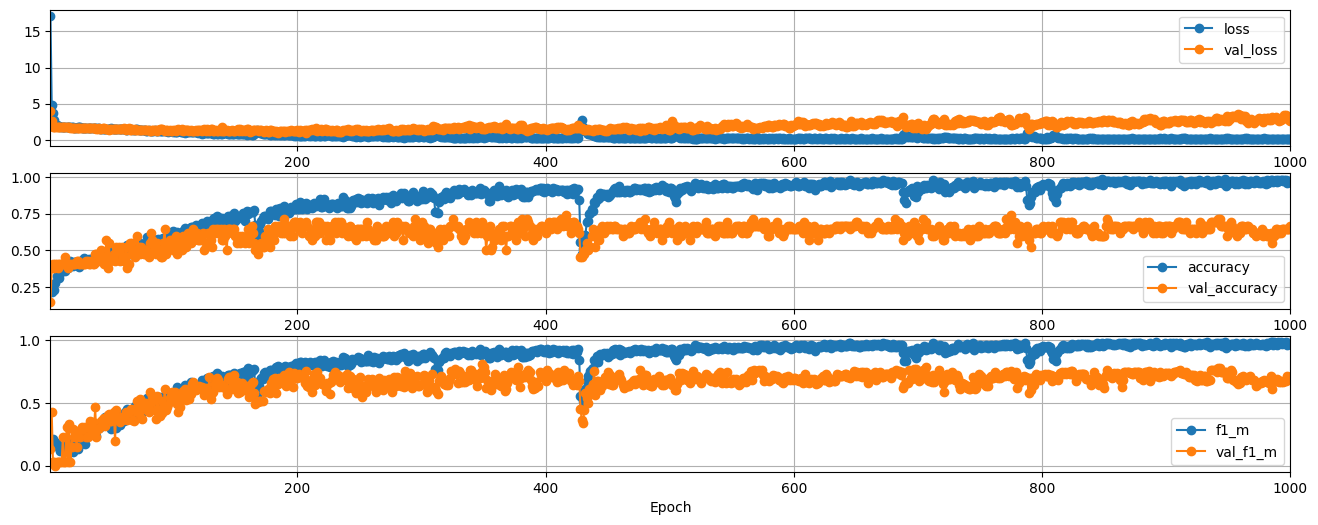

In [ ]:
plot_history(history, width=16)

In [ ]:
model.evaluate(X_test, y_test_enc)

2/2 [==============================] - 0s 36ms/step - loss: 1.5602 - accuracy: 0.7174 - f1_m: 0.7083


[1.5601905584335327, 0.717391312122345, 0.7083332538604736]

In [ ]:
prediction = model.predict(X_test)
prediction_label = argmax(prediction, axis=1)
prediction_label

2/2 [==============================] - 0s 49ms/step


array([2, 2, 2, 2, 2, 2, 6, 5, 1, 2, 6, 6, 2, 2, 2, 2, 2, 6, 2, 2, 1, 1,
       2, 6, 2, 2, 2, 0, 2, 2, 5, 2, 6, 5, 1, 3, 6, 2, 5, 4, 5, 5, 2, 1,
       2, 2])

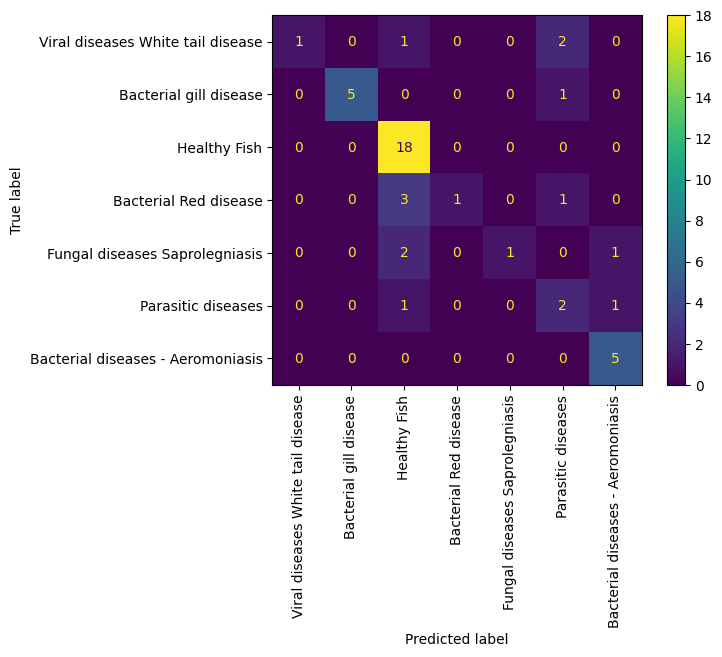

In [44]:
cm = confusion_matrix(y_pred=prediction_label,
                      y_true=y_test)
CM = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disease_names)
CM.plot(xticks_rotation=90)
plt.show()

In [45]:
## Mostrar reporte de clasificación
print(classification_report(y_pred=prediction_label,
                            y_true=y_test))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       1.00      0.83      0.91         6
           2       0.72      1.00      0.84        18
           3       1.00      0.20      0.33         5
           4       1.00      0.25      0.40         4
           5       0.33      0.50      0.40         4
           6       0.71      1.00      0.83         5

    accuracy                           0.72        46
   macro avg       0.82      0.58      0.59        46
weighted avg       0.80      0.72      0.68        46

